In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs_trading.data.loaders import load_prices
from pairs_trading.config import SplitConfig, KalmanConfig, RollingOLSConfig
from pairs_trading.models.ols_hedge import OLSHedge
from pairs_trading.models.kalman_hedge import KalmanHedge
from pairs_trading.models.rolling_ols_hedge import RollingOLSHedge
from pairs_trading.signals.zscore import rolling_zscore, generate_signal
from pairs_trading.backtest.engine import BacktestEngine

In [2]:
tickers = ["IAU", "GDX", "GLD", "SLV", "XLF", "KBE", "SPY", "IVV"]
df_train = load_prices(tickers, SplitConfig.train_start, SplitConfig.val_end, refresh=True)
df_test = load_prices(tickers, SplitConfig.test_start, SplitConfig.test_end, refresh=True)

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


In [9]:
pairs = [["IAU", "GDX"],["GLD", "SLV"], ["XLF", "KBE"], ["SPY", "IVV"]]

In [4]:
results_dict = {}
for i, (y, x) in enumerate(pairs):
    results_dict[(y,x)] = {}
    results_dict[(y,x)]['ols'] = {}
    results_dict[(y,x)]['kalman'] = {}
    results_dict[(y,x)]['rolling_ols'] = {}


    hedge_ols = OLSHedge()
    hedge_ols.fit(df_train[y], df_train[x])
    residuals_ols = hedge_ols.spread(df_test[y], df_test[x])
    zscores_ols = rolling_zscore(residuals_ols)
    signals = generate_signal(zscores_ols)
    hedge_ols_ratios = pd.Series(hedge_ols.beta, index=signals.index)
    engine_ols = BacktestEngine()
    result_ols = engine_ols.run(df_test[y], df_test[x], signals, hedge_ols_ratios)


    hedge_kalman = KalmanHedge()
    hedge_kalman.fit(df_train[y], df_train[x])
    betas, _, _ = hedge_kalman.transform(df_test[y], df_test[x])

    hedge_kalman_ratios = pd.Series(hedge_kalman.beta, index=signals.index)
    engine_kalman = BacktestEngine()
    result_kalman = engine_kalman.run(df_test[y], df_test[x], signals, hedge_kalman_ratios)

    hedge_rolling_ols = RollingOLSHedge()
    hedge_rolling_ols.fit(df_train[y], df_train[x])
    betas_roll_ols, _, _ = hedge_rolling_ols.transform(df_test[y], df_test[x])

    hedge_roll_ols_ratios = pd.Series(betas_roll_ols, index=signals.index)
    engine_roll_ols = BacktestEngine()
    result_roll_ols = engine_roll_ols.run(df_test[y], df_test[x], signals, hedge_roll_ols_ratios)

    results_dict[(y,x)]['ols']['beta'] = hedge_ols.beta
    results_dict[(y,x)]['kalman']['beta'] = betas
    results_dict[(y,x)]['rolling_ols']['beta'] = betas_roll_ols
    
    results_dict[(y,x)]['ols']['pnl'] = result_ols.pnl.cumsum()
    results_dict[(y,x)]['kalman']['pnl'] = result_kalman.pnl.cumsum()
    results_dict[(y,x)]['rolling_ols']['pnl'] = result_roll_ols.pnl.cumsum()
    
    results_dict[(y,x)]['ols']['metrics'] = result_ols.metrics
    results_dict[(y,x)]['kalman']['metrics'] = result_kalman.metrics
    results_dict[(y,x)]['rolling_ols']['metrics'] = result_roll_ols.metrics

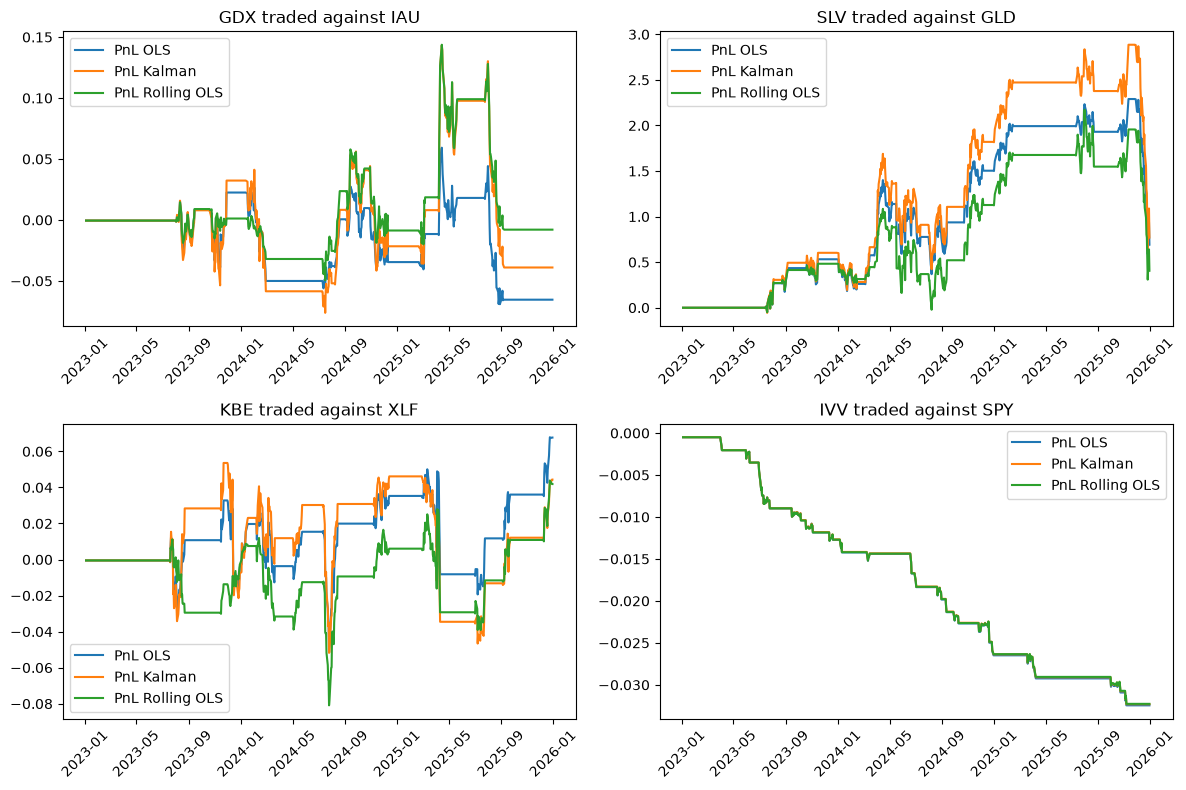

In [5]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
for i, (y, x) in enumerate(pairs):  

    axs[i].plot(results_dict[(y,x)]['ols']['pnl'], label="PnL OLS")
    axs[i].plot(results_dict[(y,x)]['kalman']['pnl'], label="PnL Kalman")
    axs[i].plot(results_dict[(y,x)]['rolling_ols']['pnl'], label="PnL Rolling OLS")
    axs[i].legend()
    axs[i].set_title(f"{x} traded against {y}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [6]:
rows = []
for (y, x), methods in results_dict.items():
    for method, data in methods.items():
        rows.append({'pair': f"{x}/{y}", 'method': method, **data['metrics']})

df = pd.DataFrame(rows).set_index(['pair', 'method'])

In [7]:
df

sharpe  max_drawdown  hit_rate  average_holding_period  \
pair    method                                                                  
GDX/IAU ols         -0.266331      0.128346  0.485944               23.800000   
        kalman      -0.110251      0.182018  0.469880               23.800000   
        rolling_ols -0.029625      0.151653  0.469880               23.800000   
SLV/GLD ols          0.234458      1.700489  0.495298               16.588235   
        kalman       0.205173      2.264086  0.495298               16.588235   
        rolling_ols  0.128049      1.864181  0.495298               16.588235   
KBE/XLF ols          0.352769      0.081507  0.502146               16.846154   
        kalman       0.187731      0.105393  0.510730               16.846154   
        rolling_ols  0.249353      0.092884  0.506438               16.846154   
IVV/SPY ols         -2.773007      0.031941  0.444444                5.304348   
        kalman      -2.759336      0.031811  0.437500                5.304348   
        rolling_ols -2.750811      0.031765  0.444444                5.304348   

                     n_trades  
pair    method                 
GDX/IAU ols                10  
        kalman             10  
        rolling_ols        10  
SLV/GLD ols                18  
        kalman             18  
        rolling_ols        18  
KBE/XLF ols                13  
        kalman             13  
        rolling_ols        13  
IVV/SPY ols                21  
        kalman             21  
        rolling_ols        21

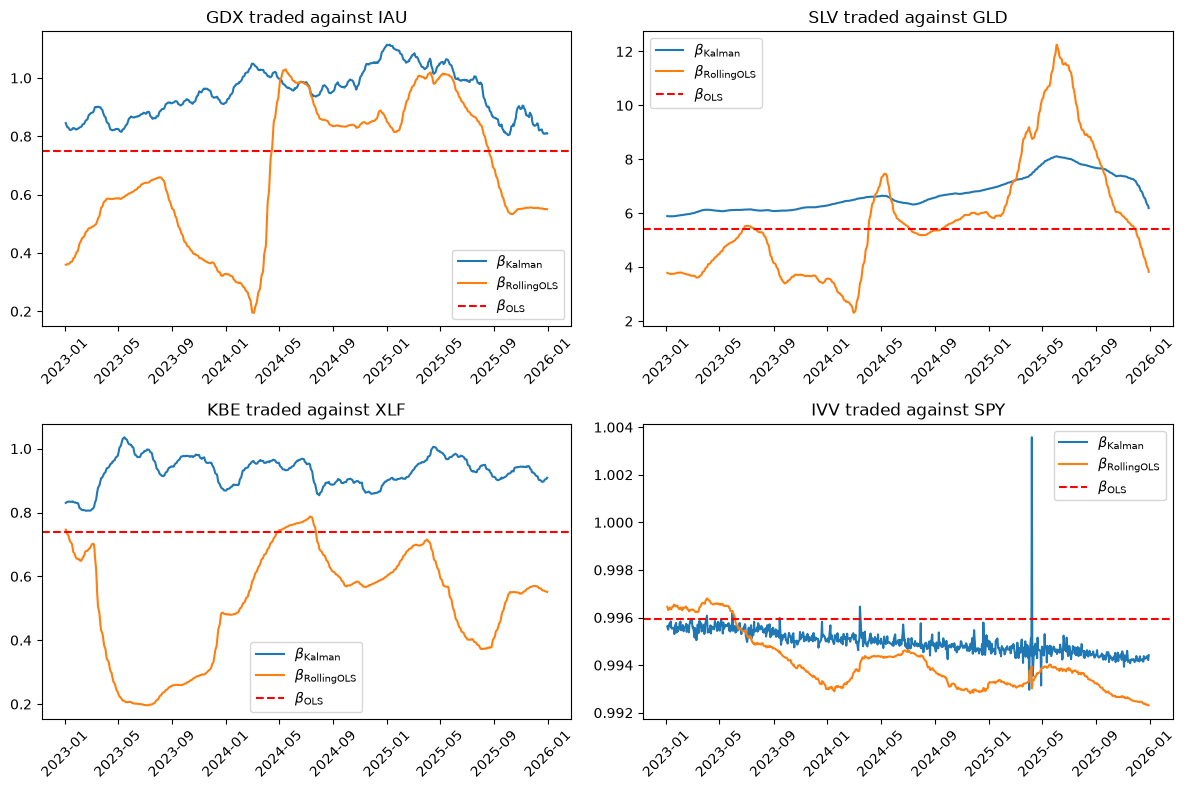

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
for i, (y, x) in enumerate(pairs):

    axs[i].plot(results_dict[(y,x)]['kalman']['beta'], label=r"$\beta_\mathrm{Kalman}$")
    axs[i].plot(results_dict[(y,x)]['rolling_ols']['beta'], label=r"$\beta_\mathrm{RollingOLS}$")

    axs[i].axhline(y=results_dict[(y,x)]['ols']['beta'], color='r', linestyle='--', label=r"$\beta_\mathrm{OLS}$")
    
    axs[i].legend()
    axs[i].set_title(f"{x} traded against {y}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [18]:
rows = []
for (y, x) in pairs:
    beta_std = results_dict[(y,x)]['rolling_ols']['beta'].std()
    kalman_sharpe_excess = (results_dict[(y,x)]['kalman']['metrics']['sharpe']
                          - results_dict[(y,x)]['ols']['metrics']['sharpe'])
    kalman_pnl_excess = (results_dict[(y,x)]['kalman']['pnl'].iloc[-1]
                       - results_dict[(y,x)]['ols']['pnl'].iloc[-1])
    rows.append({'pair': f"{x}/{y}", 'std(β_rolling)': round(beta_std, 3),
                 'Kalman − OLS Sharpe': round(kalman_sharpe_excess, 3),
                 'Kalman − OLS cumPnL': round(kalman_pnl_excess, 3)})

pd.DataFrame(rows).set_index('pair')

,std(β_rolling),Kalman − OLS Sharpe,Kalman − OLS cumPnL
pair,,,
GDX/IAU,0.234,0.156,0.026
SLV/GLD,2.211,-0.029,0.078
KBE/XLF,0.174,-0.165,-0.023
IVV/SPY,0.001,0.014,0.000
